Import all files from drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


load imports

In [2]:
import json
import pandas as pd
import seaborn as sns

Load and combine all files into one DF

In [3]:
folder = "/content/drive/MyDrive/data_center_midterm"

files = [
    folder + "/low_growth_0_market_gravity.geojson",
    folder + "/low_growth_25_market_gravity.geojson",
    folder + "/low_growth_50_market_gravity.geojson",
    folder + "/low_growth_75_market_gravity.geojson",
    folder + "/low_growth_100_market_gravity.geojson",
    folder + "/moderate_growth_0_market_gravity.geojson",
    folder + "/moderate_growth_25_market_gravity.geojson",
    folder + "/moderate_growth_50_market_gravity.geojson",
    folder + "/moderate_growth_75_market_gravity.geojson",
    folder + "/moderate_growth_100_market_gravity.geojson",
    folder + "/higher_growth_0_market_gravity.geojson",
    folder + "/higher_growth_25_market_gravity.geojson",
    folder + "/higher_growth_50_market_gravity.geojson",
    folder + "/higher_growth_75_market_gravity.geojson",
    folder + "/higher_growth_100_market_gravity.geojson",
    folder + "/high_growth_0_market_gravity.geojson",
    folder + "/high_growth_25_market_gravity.geojson",
    folder + "/high_growth_50_market_gravity.geojson",
    folder + "/high_growth_75_market_gravity.geojson",
    folder + "/high_growth_100_market_gravity.geojson"
]

In [4]:
dfs = []

for file in files:
    f = open(file, "r")
    data = json.load(f)
    f.close()

    rows = []

    for feature in data["features"]:
        rows.append(feature["properties"])

    temp_df = pd.DataFrame(rows)
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

Check the new dataframe

In [5]:
print(df.shape)
df.head()

(16645, 15)


,id,growth_scenario,market_gravity_weight,region,total_cost_million_usd,campus_size_square_ft,data_center_it_power_mw,mechanical_cooling_frac,water_cooling_frac,cooling_energy_demand_mwh,cooling_water_demand_mgy,cooling_water_consumption_mgy,normalized_locational_cost,normalized_gravity_score,weighted_siting_score
0,1_0,low,0,alabama,497.58,1000000,36,0.0,1.0,0.0,43.51968,34.815746,0.0,0.539106,0.0
1,1_1,low,0,alabama,497.58,1000000,36,0.0,1.0,0.0,43.51968,34.815746,0.0,0.329719,0.0
2,4_0,low,0,arizona,499.47,1000000,36,0.0,1.0,0.0,43.51968,34.815746,0.0,0.426766,0.0
3,4_1,low,0,arizona,499.47,1000000,36,0.0,1.0,0.0,43.51968,34.815746,0.0,0.426621,0.0
4,4_2,low,0,arizona,499.47,1000000,36,0.0,1.0,0.0,43.51968,34.815746,0.0,0.424552,0.0


In [6]:
df.columns

Index(['id', 'growth_scenario', 'market_gravity_weight', 'region',
       'total_cost_million_usd', 'campus_size_square_ft',
       'data_center_it_power_mw', 'mechanical_cooling_frac',
       'water_cooling_frac', 'cooling_energy_demand_mwh',
       'cooling_water_demand_mgy', 'cooling_water_consumption_mgy',
       'normalized_locational_cost', 'normalized_gravity_score',
       'weighted_siting_score'],
      dtype='object')

In [7]:
df["growth_scenario"].value_counts()

,count
growth_scenario,
higher,9350
high,4545
moderate,1640
low,1110


In [8]:
df["market_gravity_weight"].value_counts()

,count
market_gravity_weight,
0,3329
25,3329
50,3329
75,3329
100,3329


Save in drive

In [9]:
df.to_csv("/content/drive/MyDrive/data_center_midterm/data_centers_combined.csv", index=False)

In [10]:
df = pd.read_csv("/content/drive/MyDrive/data_center_midterm/data_centers_combined.csv")

Imports for plots

In [56]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Check for missing values

In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
id,0
growth_scenario,0
market_gravity_weight,0
region,0
total_cost_million_usd,0
campus_size_square_ft,0
data_center_it_power_mw,0
mechanical_cooling_frac,0
water_cooling_frac,0
cooling_energy_demand_mwh,0


Plot 1

Text(0, 0.5, 'Region')

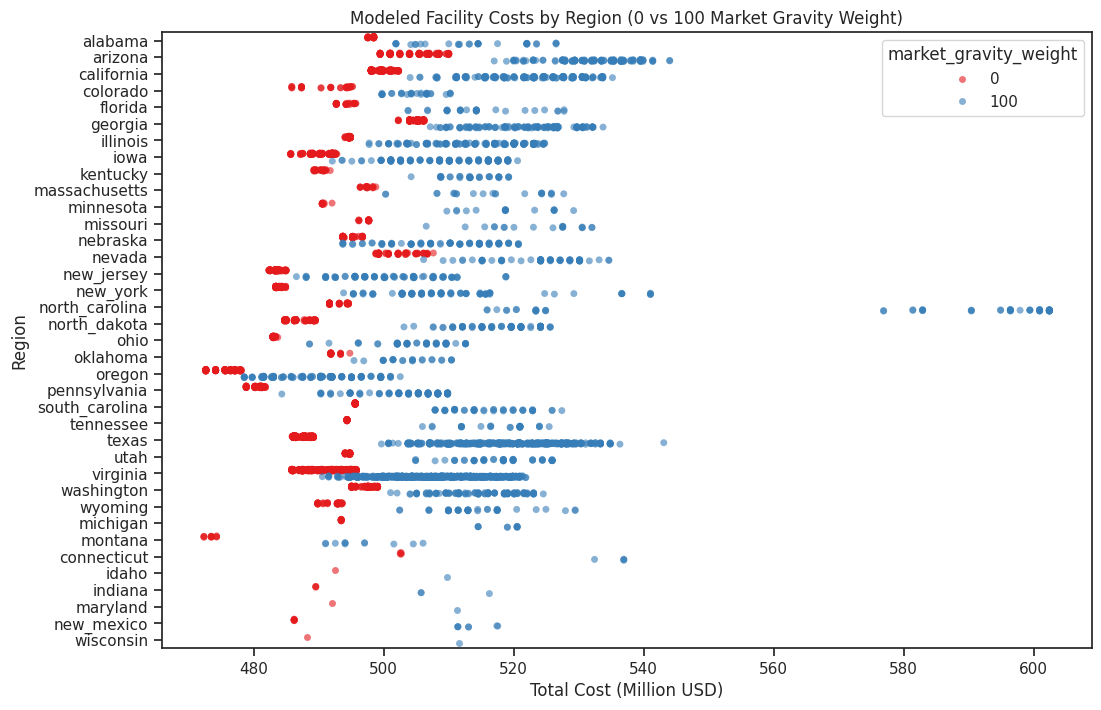

In [54]:
import seaborn as sns

plt.figure(figsize=(12, 8))
subset_df = df[df['market_gravity_weight'].isin([0, 100])]

sns.stripplot(
    data=subset_df,
    y="region",
    x="total_cost_million_usd",
    hue="market_gravity_weight",
    dodge=True,
    alpha=0.6,
    palette="Set1"
)
plt.title("Modeled Facility Costs by Region (0 vs 100 Market Gravity Weight)")
plt.xlabel("Total Cost (Million USD)")
plt.ylabel("Region")

This chart compares the total cost of building data centers under two different rules. The red dots for building where it is purely cheapest in each region and the blue dots for building close to major cities.

plot 2

Text(0, 0.5, 'Average Weighted Siting Score')

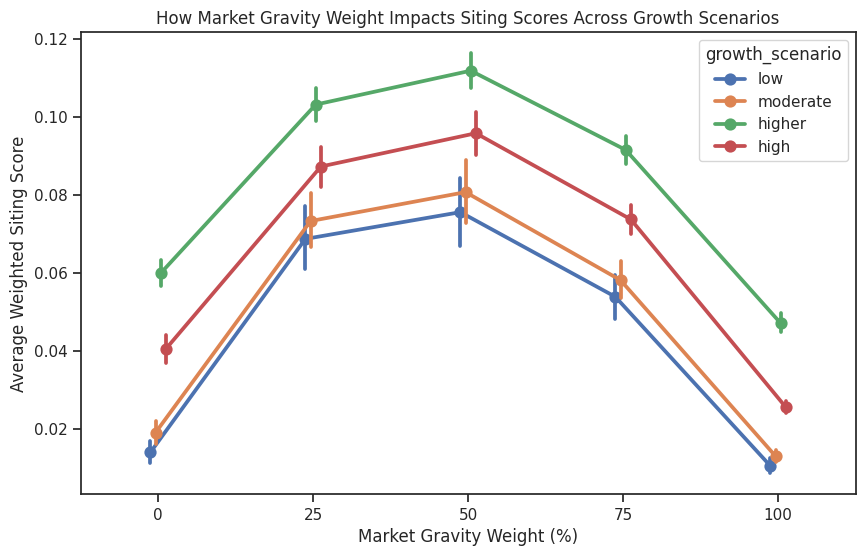

In [58]:
plt.figure(figsize=(10, 6))

sns.pointplot(
    data=df,
    x="market_gravity_weight",
    y="weighted_siting_score",
    hue="growth_scenario",
    dodge=True,
)

plt.title("How Market Gravity Weight Impacts Siting Scores Across Growth Scenarios")
plt.xlabel("Market Gravity Weight (%)")
plt.ylabel("Average Weighted Siting Score")

This chart plots the Average Weighted Siting Score  which is the locational cost and gravity score combined so essentially the winning score on the y-axis and, the Market Gravity Weight so how much we care about being close to cities on the x-axis.

plot 3

/tmp/ipykernel_10774/371779773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0, 0.5, 'Total Cost (Million USD)')

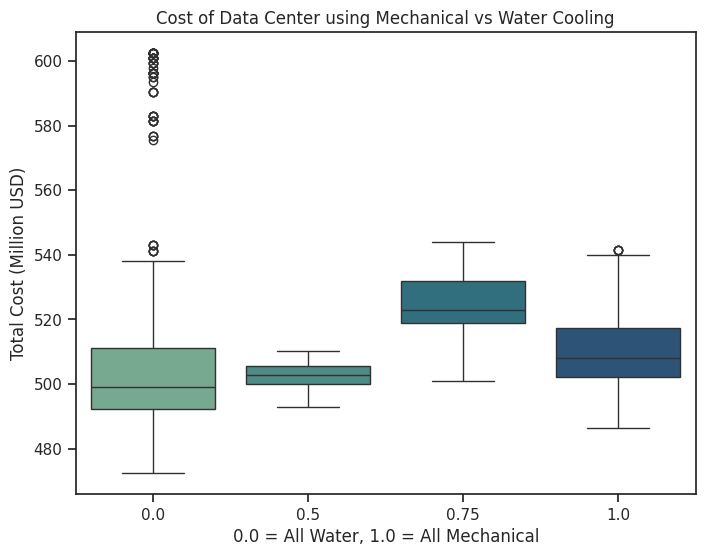

In [61]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="mechanical_cooling_frac",
    y="total_cost_million_usd",
    palette="crest"
)

plt.title("Cost of Data Center using Mechanical vs Water Cooling")
plt.xlabel("0.0 = All Water, 1.0 = All Mechanical")
plt.ylabel("Total Cost (Million USD)")

This plot groups the data centers by cooling type and shows a range of how much they might cost.